# Exploratory Data Analysis (EDA) of Compound-Gene Interactions
**Target Genes:** CYP450 Family

This notebook presents an exploratory analysis of compound interactions with five Cytochrome P450 enzymes (CYP1A2, CYP2C9, CYP2C19, CYP2D6, and CYP3A4). The dataset includes information on interaction types and actions extracted from a compound-gene interaction knowledge graph. This analysis supports understanding of interaction diversity, compound promiscuity, and interaction distribution.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

In [2]:
# Load the data
file_path = '../import/processed_compound_gene_interactions.csv'
data = pd.read_csv(file_path)
data.columns = [col.strip().replace(' ', '_') for col in data.columns]
data.head()

C:\Users\Asmaa_Ali\AppData\Local\Temp\ipykernel_6056\3599473118.py:3: DtypeWarning: Columns (53,54,55,56,57,58,59,60,61,62,64,65,66,67,68,70,71,72,73) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


,Compound_IsomericSMILES,Compound_ExactMass,Compound_XStericQuadrupole3D,Compound_InChI,Compound_FeatureCationCount3D,Compound_IsotopeAtomCount,Compound_IUPACName,Compound_Volume3D,Compound_PatentFamilyCount,Compound_StructureImage2DURL,...,Interaction_protname,Interaction_dois,Interaction_evurls,Interaction_protacxn,Interaction_srccmpdname,Interaction_id,Interaction_srctarget,Interaction_dsn,Interaction_actname,Interaction_action
0,COC1=NC=C(C=N1)C2=CC3=C(NC=C3C(=O)C4=C(C=CC(=C...,557.078088,20.53,InChI=1S/C25H15F4N5O4S/c1-38-25-32-9-13(10-33-...,2.0,0,"N-[2,4-difluoro-3-[5-(2-methoxypyrimidin-5-yl)...",391.1,1.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CN1CCN(CC1)CC2=C(C=CC(=C2)NC3=C4C=C(C=CC4=NC5=...,462.182254,9.35,InChI=1S/C26H27ClN4O2/c1-30-9-11-31(12-10-30)1...,3.0,0,4-[(6-chloro-2-methoxyacridin-9-yl)amino]-2-[(...,354.3,6.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,COC(=O)N[C@H](C1=CC=CC=C1)C(=O)N2CCC[C@H]2C(=O...,796.303219,NaN,InChI=1S/C42H42F2N6O8/c1-57-41(55)47-35(25-11-...,NaN,0,methyl N-[(1R)-2-[(2S)-2-[[3-fluoro-4-[2-fluor...,NaN,1.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CC(C)C[C@@H](C(=O)N[C@@H](C[C@@H]1CCNC1=O)C(=O...,575.220240,22.32,InChI=1S/C30H33N5O5S/c1-16(2)13-22(34-29(39)23...,1.0,0,"N-[(2S)-1-[[(2S)-1-(1,3-benzothiazol-2-yl)-1-o...",441.9,3.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CN1C[C@H]2CCCC[C@]2(C1)C3=CC(=C(C=C3)Cl)Cl,283.089455,7.34,"InChI=1S/C15H19Cl2N/c1-18-9-12-4-2-3-7-15(12,1...",1.0,0,"(3aS,7aR)-7a-(3,4-dichlorophenyl)-2-methyl-3,3...",211.6,1.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Preprocessing: Filter for relevant genes and clean interaction types
required_columns = ['Gene_GeneSymbol', 'InteractionType', 'Interaction_action', 'Compound_CompoundID']
for col in required_columns:
    assert col in data.columns, f'Missing column: {col}'

data['InteractionType'] = data['InteractionType'].str.lower()
data['Interaction_action'] = data['Interaction_action'].str.lower()
mask = (data['InteractionType'] == 'interacts_with') & (data['Interaction_action'].str.len() < 20)
data.loc[mask, 'InteractionType'] = data.loc[mask, 'Interaction_action']
included_interactions = ['inhibitor', 'inhibit', 'inactive']
data = data[data.InteractionType.isin(included_interactions)]
specified_genes = ['CYP1A2', 'CYP2C9', 'CYP2C19', 'CYP2D6', 'CYP3A4']
data = data[data['Gene_GeneSymbol'].isin(specified_genes)]
data['InteractionType'] = data['InteractionType'].replace('inhibitor', 'inhibit')
data.shape

(279685, 74)

In [4]:
# Descriptive statistics of numeric columns (if any)
data.describe(include='all')

,Compound_IsomericSMILES,Compound_ExactMass,Compound_XStericQuadrupole3D,Compound_InChI,Compound_FeatureCationCount3D,Compound_IsotopeAtomCount,Compound_IUPACName,Compound_Volume3D,Compound_PatentFamilyCount,Compound_StructureImage2DURL,...,Interaction_protname,Interaction_dois,Interaction_evurls,Interaction_protacxn,Interaction_srccmpdname,Interaction_id,Interaction_srctarget,Interaction_dsn,Interaction_actname,Interaction_action
count,279685,279685.000000,260190.000000,279685,260190.000000,279685.000000,279464,260190.000000,77461.000000,279685,...,459,6,297,459,459,4.590000e+02,459,459,6,459
unique,120772,NaN,NaN,120754,NaN,NaN,120698,NaN,NaN,120776,...,5,1,224,5,314,NaN,11,5,1,1
top,CC1=C(N=CN1)CSCCNC(=NC)NC#N,NaN,NaN,InChI=1S/C10H16N6S/c1-8-9(16-7-15-8)5-17-4-3-1...,NaN,NaN,"3-[(1R,2S)-2-amino-1-hydroxypropyl]phenol;(2R,...",NaN,NaN,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,Cytochrome P450 2D6,['10.1021/jm060519r'],['https://www.ncbi.nlm.nih.gov/pubmed/17125252...,P10635,Methimazole,NaN,BE0002363,DrugBank,Ki (nM),inhibitor
freq,15,NaN,NaN,15,NaN,NaN,20,NaN,NaN,15,...,131,6,6,131,5,NaN,87,325,6,459
mean,NaN,346.167155,13.175079,NaN,0.727326,0.000186,NaN,258.474773,4263.206026,NaN,...,NaN,NaN,NaN,NaN,NaN,1.304515e+06,NaN,NaN,NaN,NaN
std,NaN,108.213796,6.660344,NaN,0.884303,0.026741,NaN,69.355820,15689.750524,NaN,...,NaN,NaN,NaN,NaN,NaN,6.691124e+05,NaN,NaN,NaN,NaN
min,NaN,30.010565,0.930000,NaN,0.000000,0.000000,NaN,25.200000,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,4.746900e+04,NaN,NaN,NaN,NaN
25%,NaN,282.109231,8.420000,NaN,0.000000,0.000000,NaN,215.200000,2.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,5.706335e+05,NaN,NaN,NaN,NaN
50%,NaN,343.135448,11.820000,NaN,0.000000,0.000000,NaN,259.200000,75.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,1.512055e+06,NaN,NaN,NaN,NaN
75%,NaN,406.179361,16.590000,NaN,1.000000,0.000000,NaN,304.600000,2505.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,1.934112e+06,NaN,NaN,NaN,NaN


In [5]:
# Count of each interaction type per gene
interaction_counts = data.groupby(['Gene_GeneSymbol', 'InteractionType']).size().reset_index(name='Count')
interaction_counts

,Gene_GeneSymbol,InteractionType,Count
0,CYP1A2,inactive,9015
1,CYP1A2,inhibit,7636
2,CYP2C19,inactive,102028
3,CYP2C19,inhibit,3907
4,CYP2C9,inactive,103670
5,CYP2C9,inhibit,5735
6,CYP2D6,inactive,15161
7,CYP2D6,inhibit,5065
8,CYP3A4,inactive,20574
9,CYP3A4,inhibit,6894


In [6]:
# Count compounds with "INTERACTS_WITH" and another relationship
interacts_with_data = data[data["InteractionType"] == "interacts_with"]
other_relationship_data = data[data["InteractionType"] != "interacts_with"]

compound_gene_interactions = pd.merge(
    interacts_with_data,
    other_relationship_data,
    on=["Compound_CompoundID", "Gene_GeneSymbol"],
    suffixes=("_interacts", "_other"),
)
compounds_with_multiple_relationships = compound_gene_interactions[
    "Compound_CompoundID"
].nunique()
print(
    f"Compounds with 'INTERACTS_WITH' and another relationship: {compounds_with_multiple_relationships}"
)
compound_gene_interactions

Compounds with 'INTERACTS_WITH' and another relationship: 0


,Compound_IsomericSMILES_interacts,Compound_ExactMass_interacts,Compound_XStericQuadrupole3D_interacts,Compound_InChI_interacts,Compound_FeatureCationCount3D_interacts,Compound_IsotopeAtomCount_interacts,Compound_IUPACName_interacts,Compound_Volume3D_interacts,Compound_PatentFamilyCount_interacts,Compound_StructureImage2DURL_interacts,...,Interaction_protname_other,Interaction_dois_other,Interaction_evurls_other,Interaction_protacxn_other,Interaction_srccmpdname_other,Interaction_id_other,Interaction_srctarget_other,Interaction_dsn_other,Interaction_actname_other,Interaction_action_other


In [7]:
# Count unique genes each compound interacts with
compound_gene_count = (
    data.groupby("Compound_CompoundID")["Gene_GeneSymbol"]
    .nunique()
    .reset_index(name="UniqueGeneCount")
)
compound_gene_count

,Compound_CompoundID,UniqueGeneCount
0,4,5
1,6,3
2,11,5
3,13,5
4,33,4
...,...,...
120771,171357078,1
120772,171358533,1
120773,171358589,1
120774,171358782,1


In [8]:
# 1. Compounds interacting with all specified genes
compounds_with_all_genes = compound_gene_count[
    compound_gene_count["UniqueGeneCount"] == len(specified_genes)
]
num_compounds_with_all_genes = compounds_with_all_genes.shape[0]
print(f"Compounds interacting with all genes: {num_compounds_with_all_genes}")
compounds_with_all_genes

Compounds interacting with all genes: 8081


,Compound_CompoundID,UniqueGeneCount
0,4,5
2,11,5
3,13,5
5,34,5
6,51,5
...,...,...
120673,166642340,5
120674,166642341,5
120684,167427876,5
120721,168297478,5


In [9]:
# 2. Compounds interacting with at least one gene
num_compounds_with_at_least_one_gene = compound_gene_count[
    (compound_gene_count["UniqueGeneCount"] > 1)
    & (compound_gene_count["UniqueGeneCount"] < 5)
].shape[0]
print(
    f"Compounds interacting with at least one gene: {num_compounds_with_at_least_one_gene}"
)

Compounds interacting with at least one gene: 103896


In [10]:
# 3. Compounds interacting with exactly one gene
num_compounds_with_one_gene = compound_gene_count[
    compound_gene_count["UniqueGeneCount"] == 1
].shape[0]
print(f"Compounds interacting with exactly one gene: {num_compounds_with_one_gene}")

# Save these stats
compound_gene_count

Compounds interacting with exactly one gene: 8799


,Compound_CompoundID,UniqueGeneCount
0,4,5
1,6,3
2,11,5
3,13,5
4,33,4
...,...,...
120771,171357078,1
120772,171358533,1
120773,171358589,1
120774,171358782,1


In [11]:
# Interaction counts by type and gene
interaction_counts = (
    data.groupby(["Gene_GeneSymbol", "InteractionType"])
    .size()
    .reset_index(name="Count")
)
interaction_counts


,Gene_GeneSymbol,InteractionType,Count
0,CYP1A2,inactive,9015
1,CYP1A2,inhibit,7636
2,CYP2C19,inactive,102028
3,CYP2C19,inhibit,3907
4,CYP2C9,inactive,103670
5,CYP2C9,inhibit,5735
6,CYP2D6,inactive,15161
7,CYP2D6,inhibit,5065
8,CYP3A4,inactive,20574
9,CYP3A4,inhibit,6894


In [12]:
# Descriptive statistics for numeric fields
numeric_cols = data.select_dtypes(include=["float64", "int64"]).columns
numeric_stats = data[numeric_cols].describe()
numeric_stats

,Compound_ExactMass,Compound_XStericQuadrupole3D,Compound_FeatureCationCount3D,Compound_IsotopeAtomCount,Compound_Volume3D,Compound_PatentFamilyCount,Compound_Complexity,Compound_PatentCount,Compound_FeatureHydrophobeCount3D,Compound_MonoisotopicMass,...,Compound_XLogP,Compound_EffectiveRotorCount3D,Compound_AtomStereoCount,Compound_ConformerModelRMSD3D,Compound_FeatureAcceptorCount3D,Gene_TaxonomyID,Gene_GeneID,Interaction_AssayID,Interaction_taxid,Interaction_id
count,279685.000000,260190.000000,260190.000000,279685.000000,260190.000000,77461.000000,279685.000000,7.746100e+04,260190.000000,279685.000000,...,263392.000000,260190.000000,279685.000000,260190.000000,260190.000000,279685.0,279685.000000,2.792260e+05,459.0,4.590000e+02
mean,346.167155,13.175079,0.727326,0.000186,258.474773,4263.206026,482.837785,1.212057e+04,0.316369,346.153599,...,2.783042,5.961603,0.638901,0.813644,2.766117,9606.0,1559.452927,2.865858e+05,9606.0,1.304515e+06
std,108.213796,6.660344,0.884303,0.026741,69.355820,15689.750524,218.806117,3.589287e+04,0.639527,108.202141,...,1.627703,2.793837,1.663986,0.217443,1.523204,0.0,6.759561,6.115105e+05,0.0,6.691124e+05
min,30.010565,0.930000,0.000000,0.000000,25.200000,1.000000,0.000000,1.000000e+00,0.000000,30.010565,...,-17.200000,0.000000,0.000000,0.400000,0.000000,9606.0,1544.000000,4.100000e+02,9606.0,4.746900e+04
25%,282.109231,8.420000,0.000000,0.000000,215.200000,2.000000,346.000000,7.000000e+00,0.000000,282.107653,...,1.900000,4.000000,0.000000,0.600000,2.000000,9606.0,1557.000000,1.024000e+03,9606.0,5.706335e+05
50%,343.135448,11.820000,0.000000,0.000000,259.200000,75.000000,469.000000,2.260000e+02,0.000000,343.135448,...,2.800000,6.000000,0.000000,0.800000,3.000000,9606.0,1559.000000,1.025000e+03,9606.0,1.512055e+06
75%,406.179361,16.590000,1.000000,0.000000,304.600000,2505.000000,603.000000,7.828000e+03,0.000000,406.175339,...,3.700000,8.000000,1.000000,1.000000,4.000000,9606.0,1559.000000,1.025000e+03,9606.0,1.934112e+06
max,1875.540932,99.010000,6.000000,6.000000,585.700000,963835.000000,3980.000000,1.476513e+06,11.000000,1875.540932,...,25.900000,18.000000,40.000000,2.000000,18.000000,9606.0,1576.000000,1.963537e+06,9606.0,2.141292e+06


## Figures

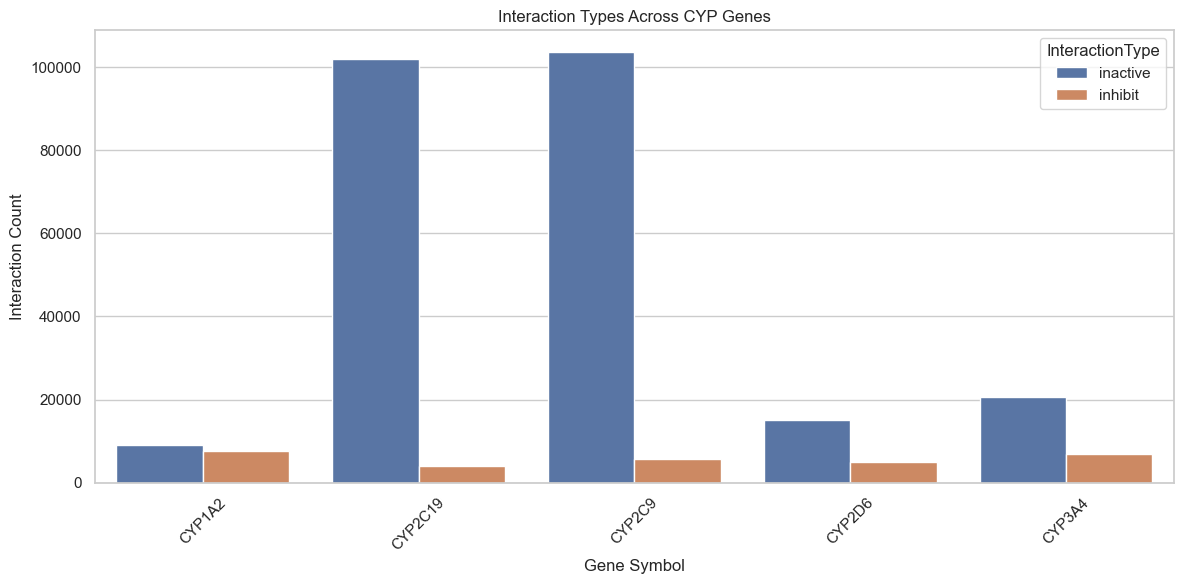

In [13]:
# Bar plot: Interaction counts by gene and type
plt.figure(figsize=(12, 6))
sns.barplot(data=interaction_counts, x='Gene_GeneSymbol', y='Count', hue='InteractionType')
plt.title('Interaction Types Across CYP Genes')
plt.xlabel('Gene Symbol')
plt.ylabel('Interaction Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

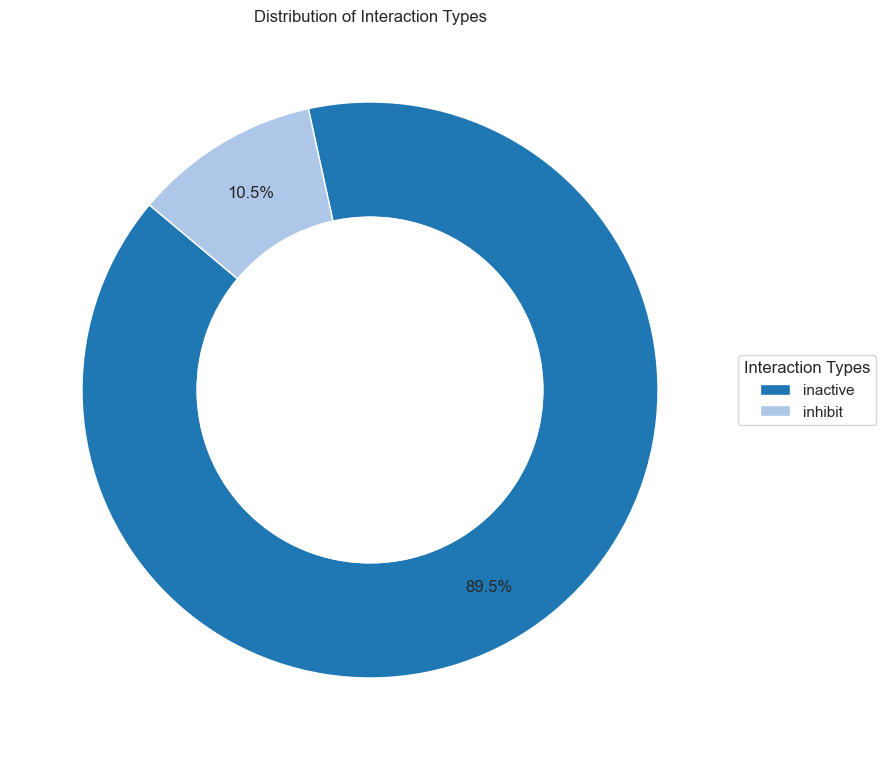

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Prepare data
interaction_counts = data['InteractionType'].value_counts()
threshold = 0.01  # Set threshold for combining rare interactions
total = interaction_counts.sum()

# Group small slices into "Other"
major_interactions = interaction_counts[interaction_counts / total > threshold]
minor_interactions = interaction_counts[interaction_counts / total <= threshold]
if not minor_interactions.empty:
    major_interactions['Other'] = minor_interactions.sum()

# Step 2: Plot
fig, ax = plt.subplots(figsize=(9, 9))
colors = plt.cm.tab20.colors[:len(major_interactions)]  # limit to n colors

wedges, texts, autotexts = ax.pie(
    major_interactions,
    labels=None,
    startangle=140,
    colors=colors,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 2 else '',  # Hide very small %s
    pctdistance=0.8,
    wedgeprops=dict(width=0.4)
)

# Step 3: Add circle for donut
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig.gca().add_artist(centre_circle)

# Step 4: Add legend
ax.legend(
    wedges,
    major_interactions.index,
    title="Interaction Types",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

# Step 5: Final touches
plt.title('Distribution of Interaction Types')
plt.tight_layout()
plt.show()



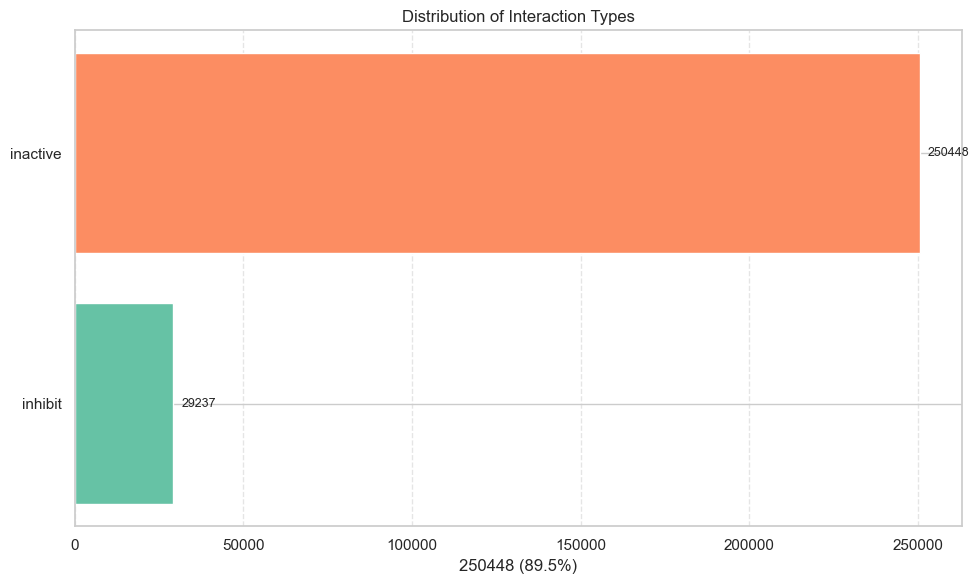

In [15]:
import matplotlib.pyplot as plt

# Count the interaction types
interaction_counts = data['InteractionType'].value_counts()

# Sort from largest to smallest
interaction_counts = interaction_counts.sort_values(ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(interaction_counts.index, interaction_counts.values, color=plt.cm.Set2.colors)

# Add labels to each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + max(interaction_counts.values) * 0.01, bar.get_y() + bar.get_height()/2,
            f'{width}', va='center', fontsize=9)

# Titles and labels
ax.set_xlabel(f'{width} ({width / interaction_counts.sum():.1%})', fontsize=12)
ax.set_title('Distribution of Interaction Types')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Optional: Save as image
# plt.savefig("interaction_type_barplot.png", dpi=300)

plt.show()


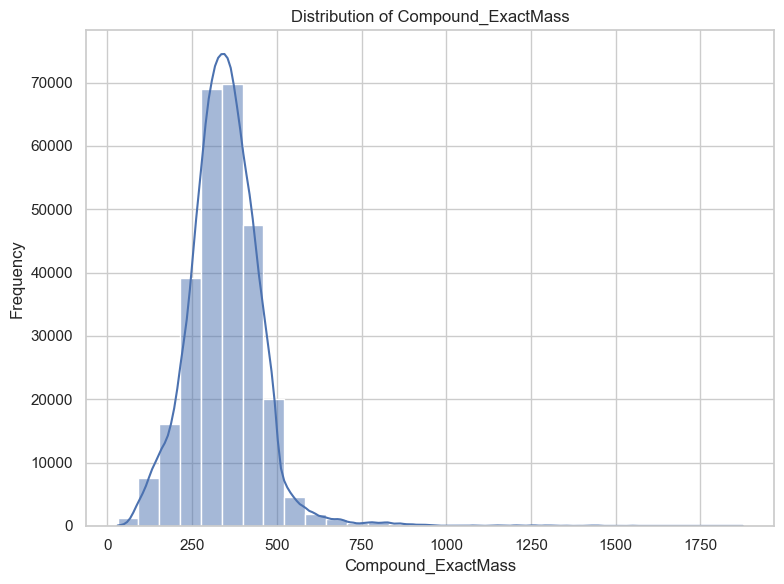

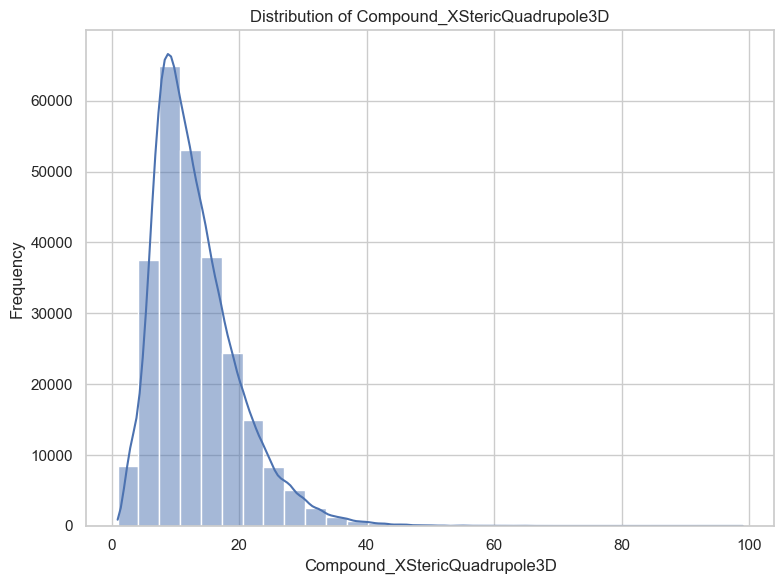

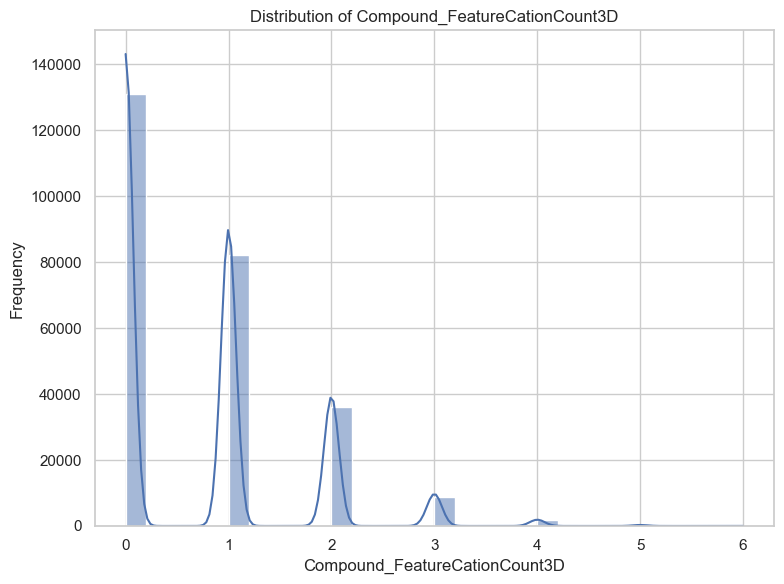

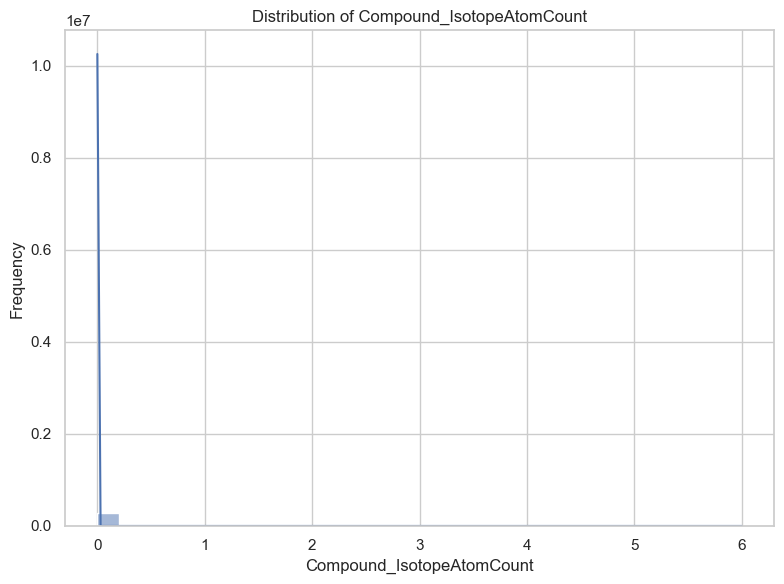

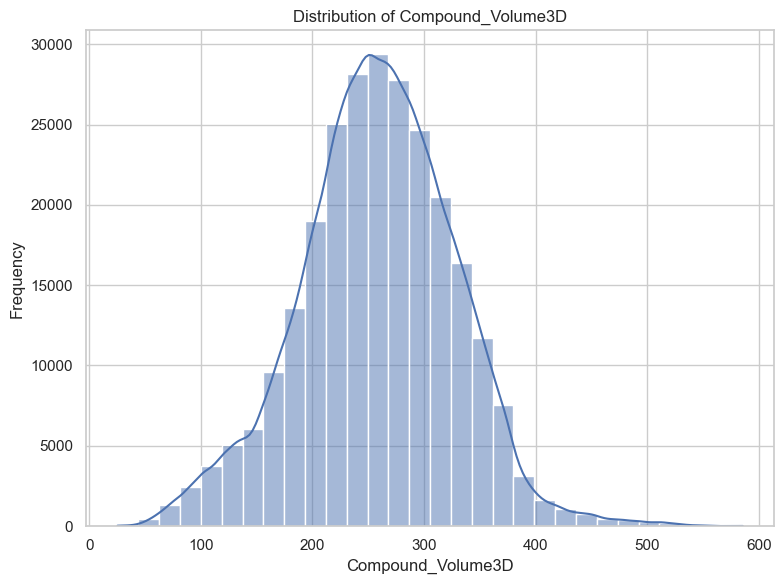

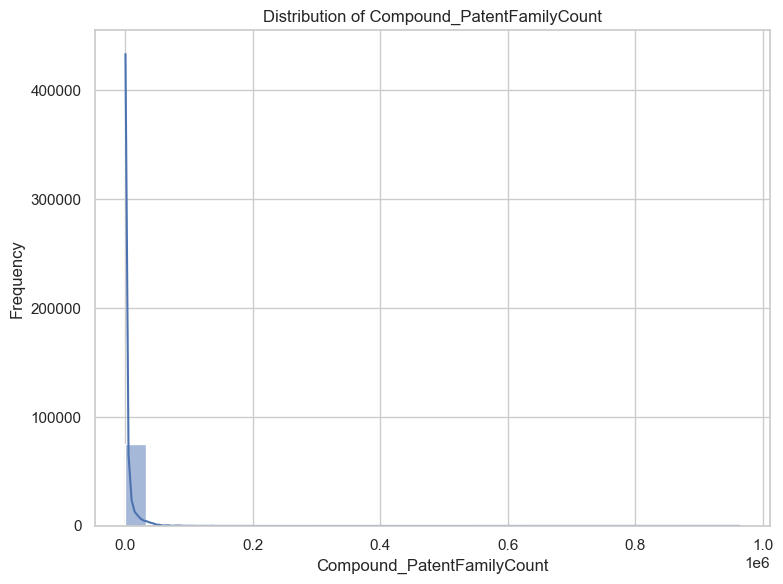

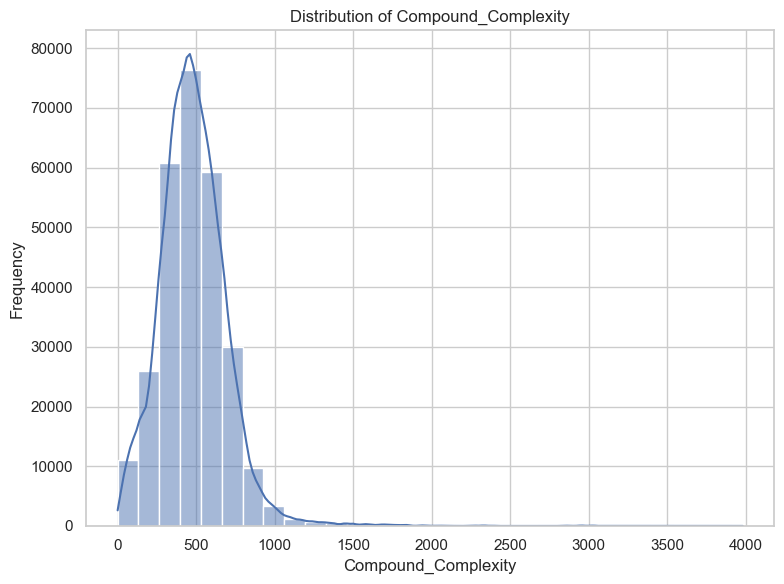

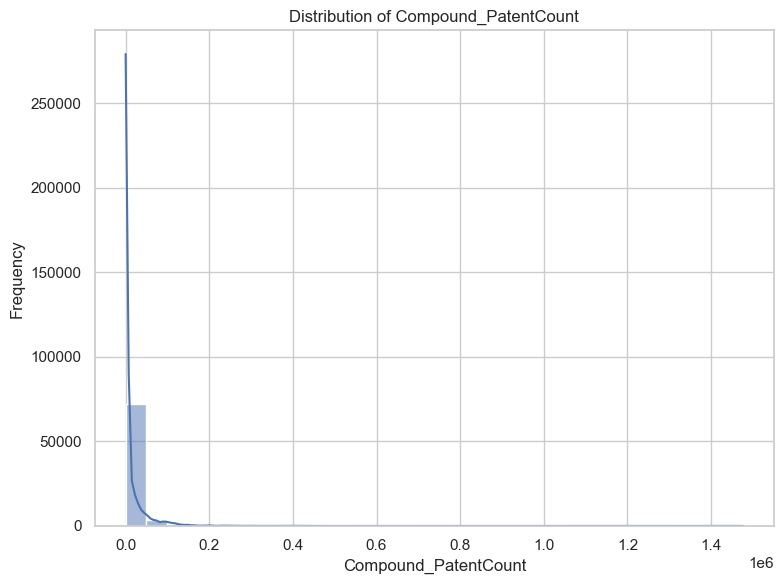

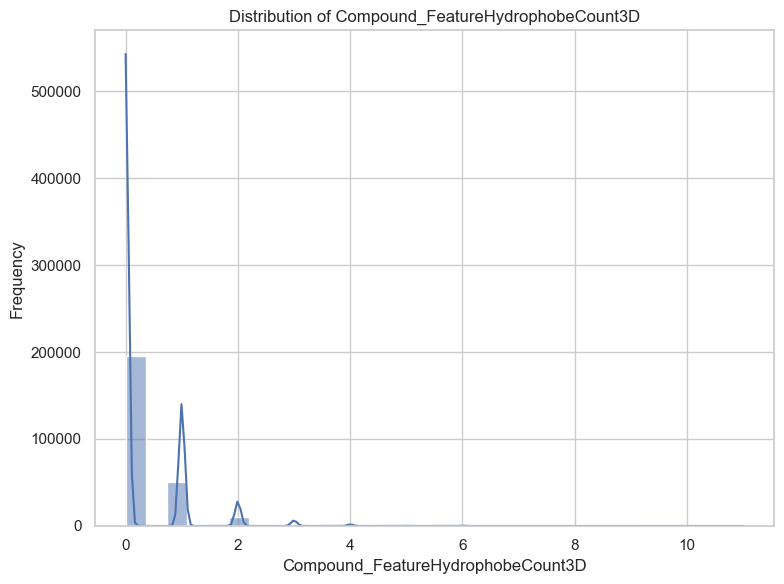

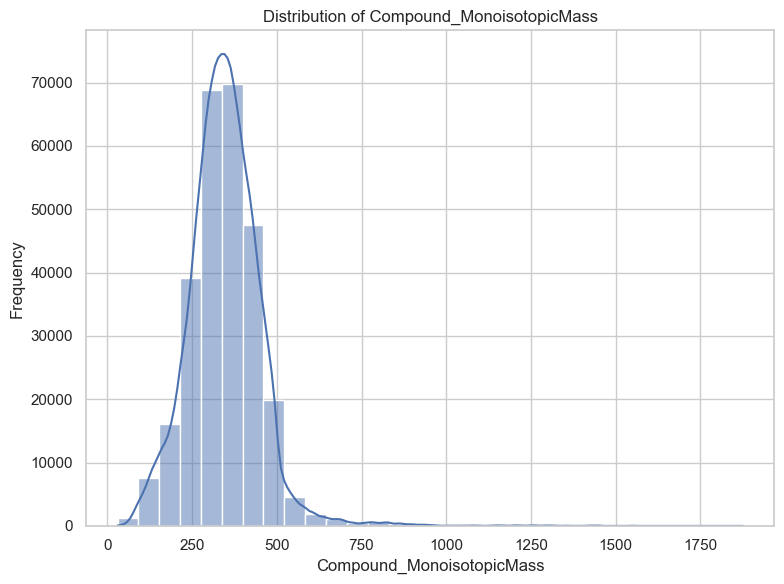

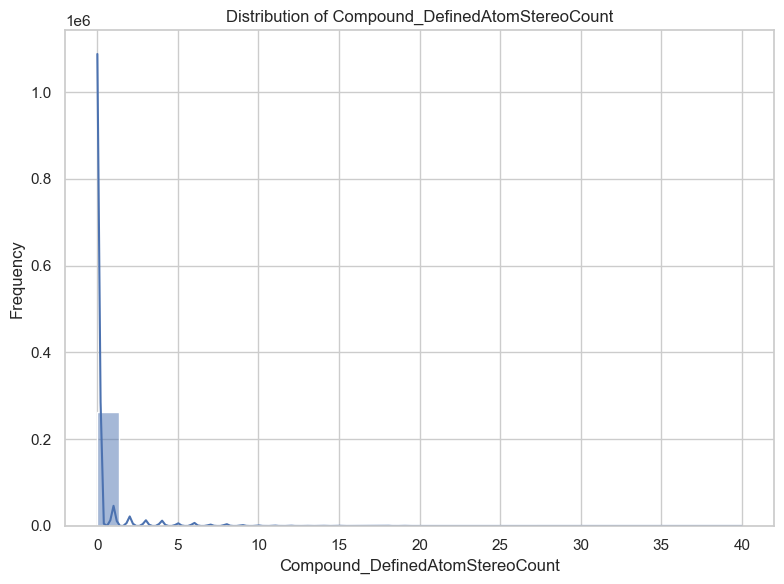

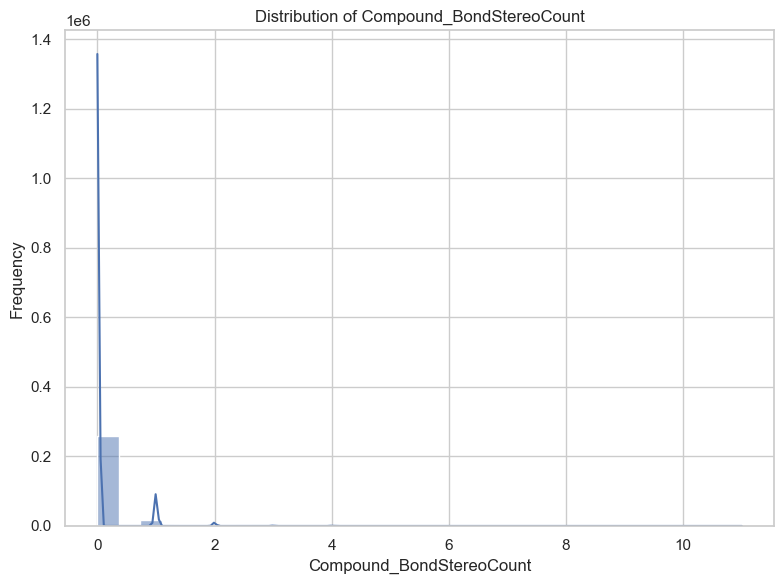

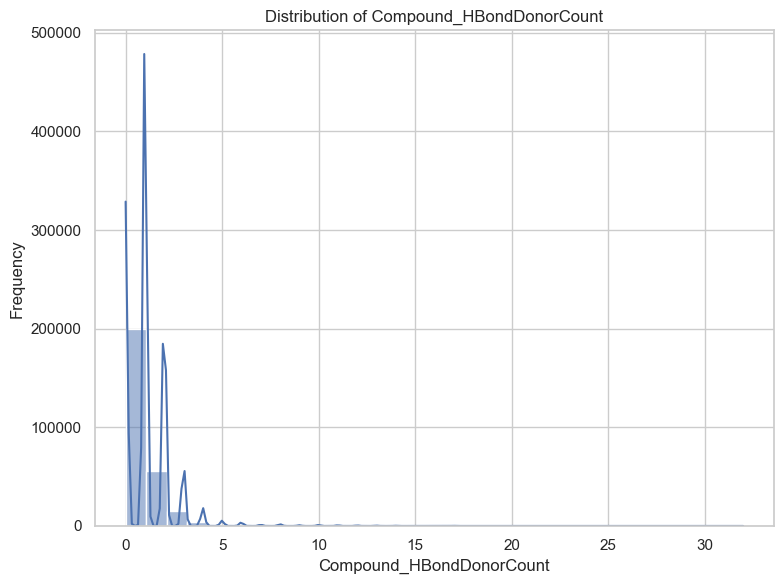

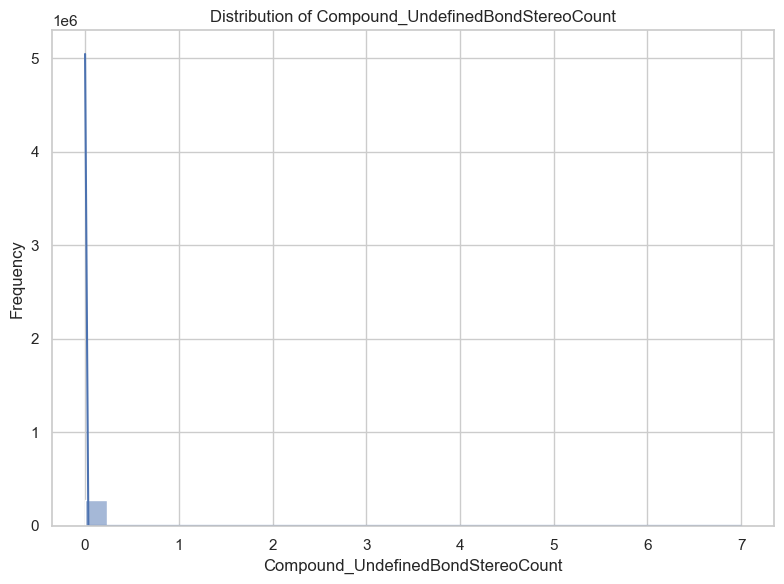

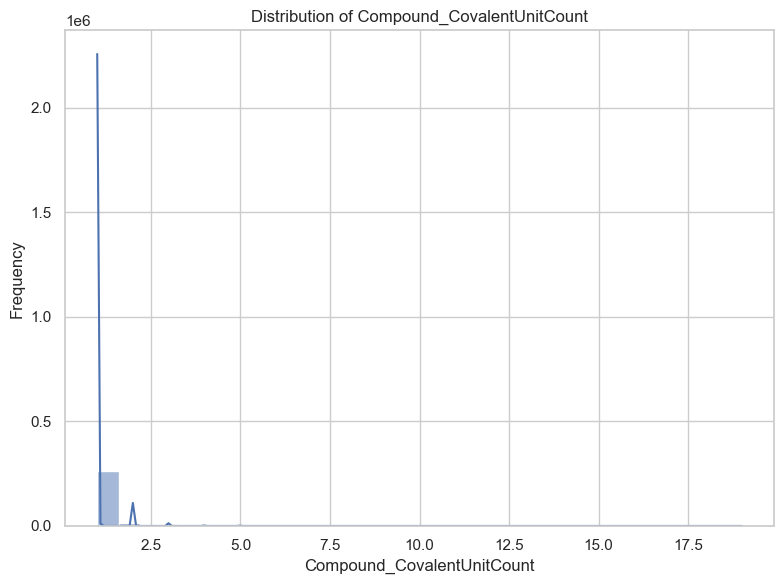

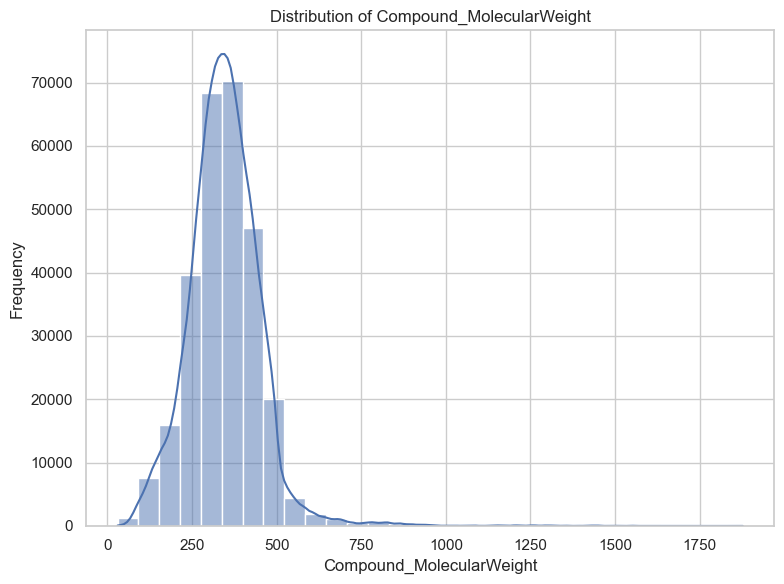

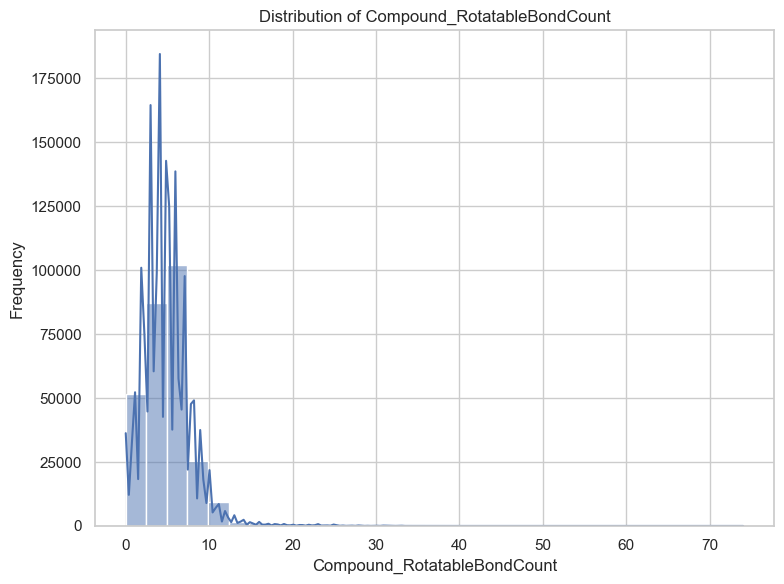

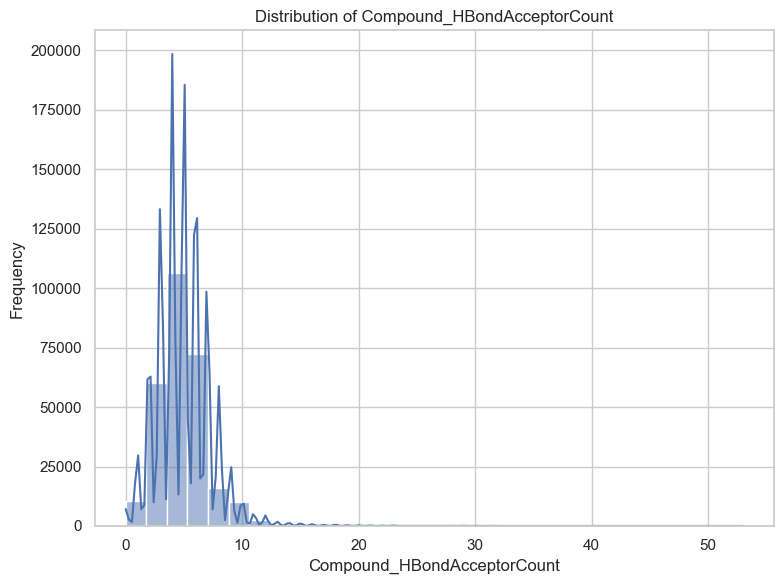

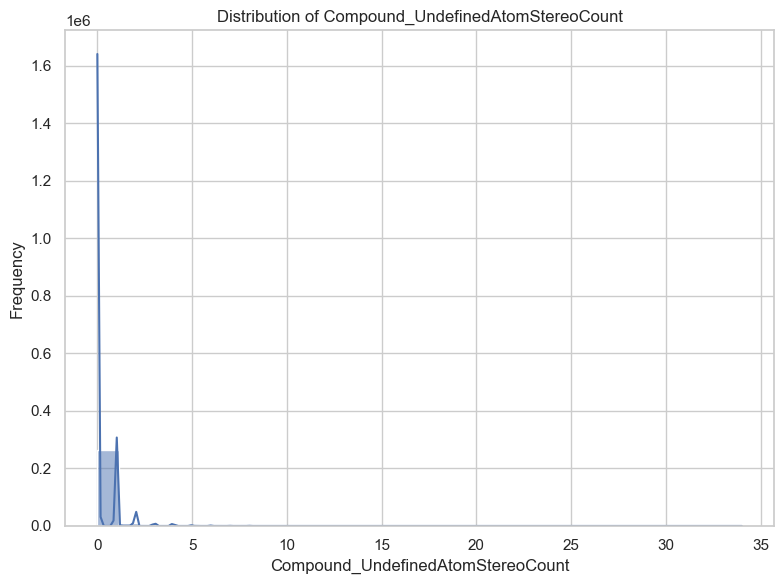

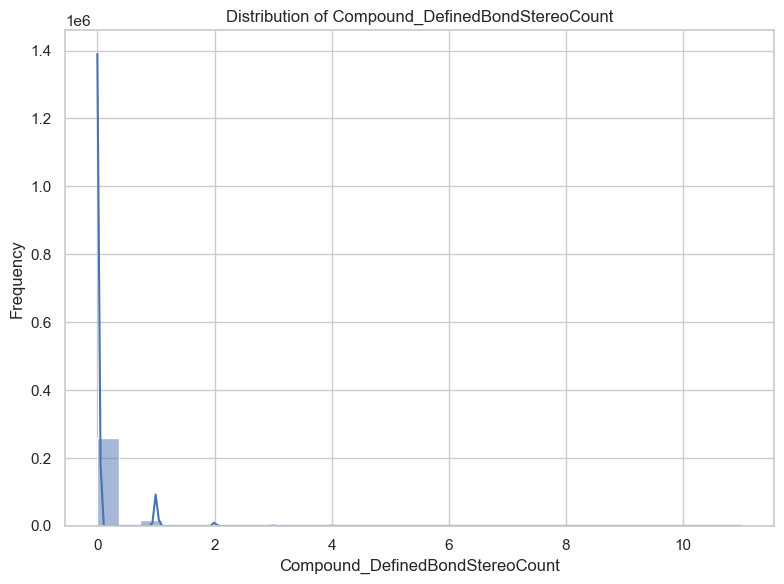

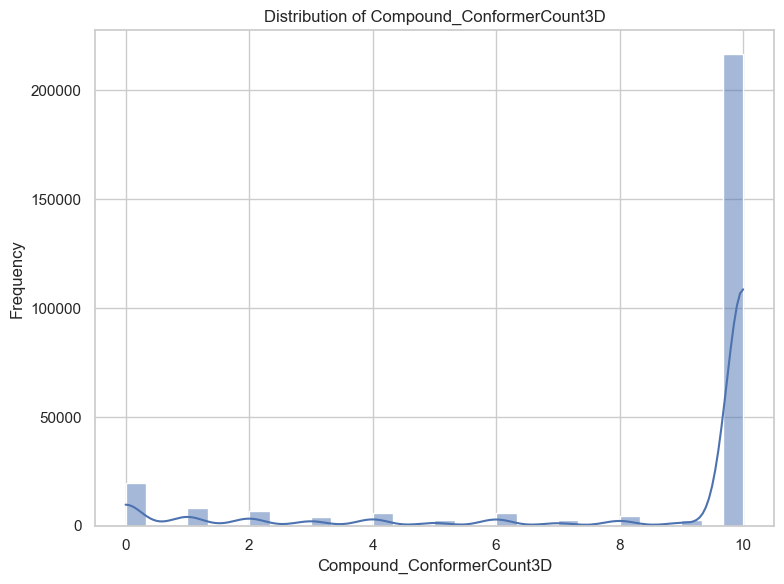

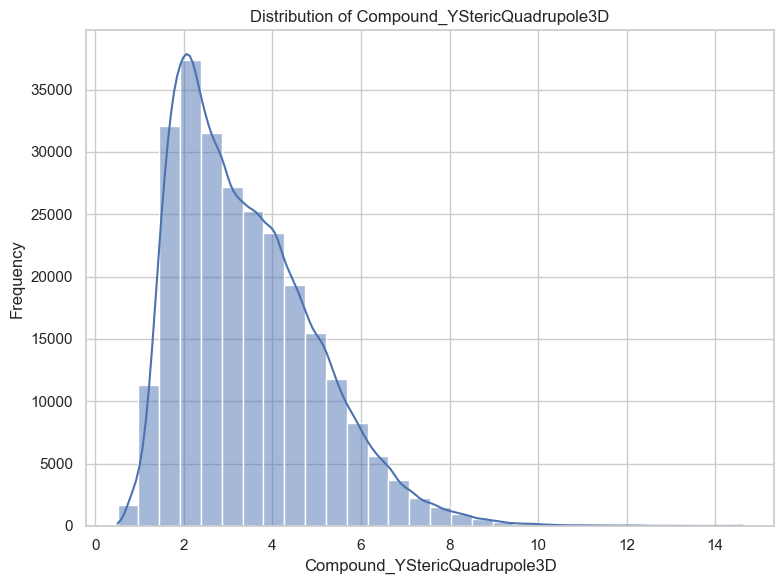

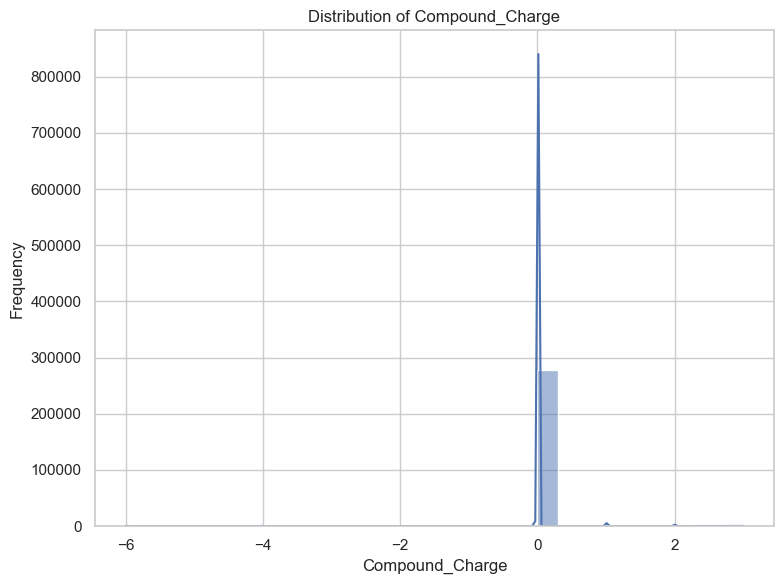

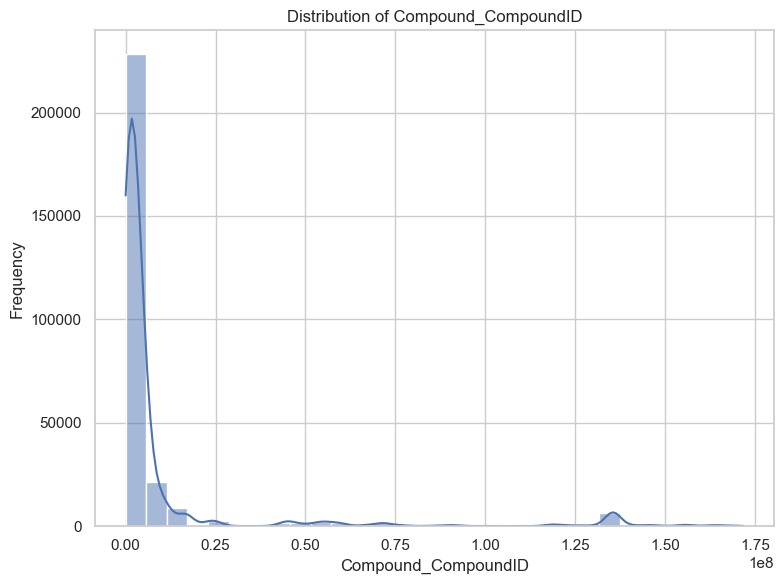

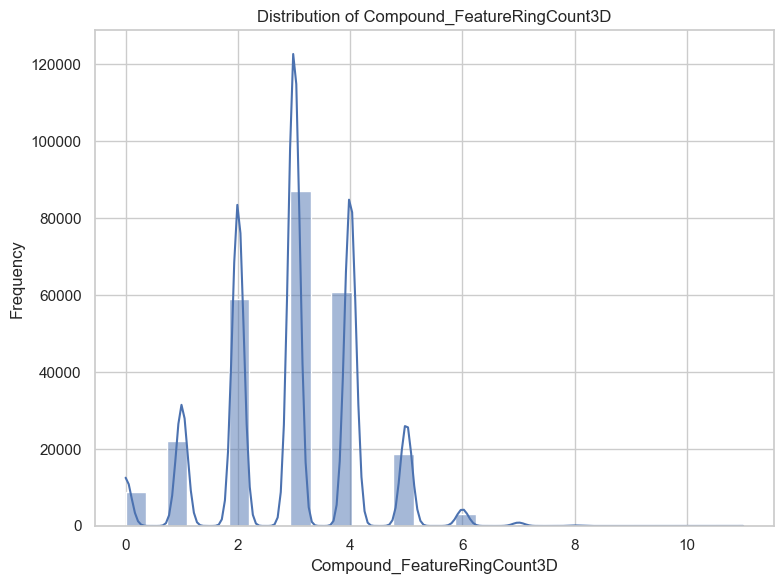

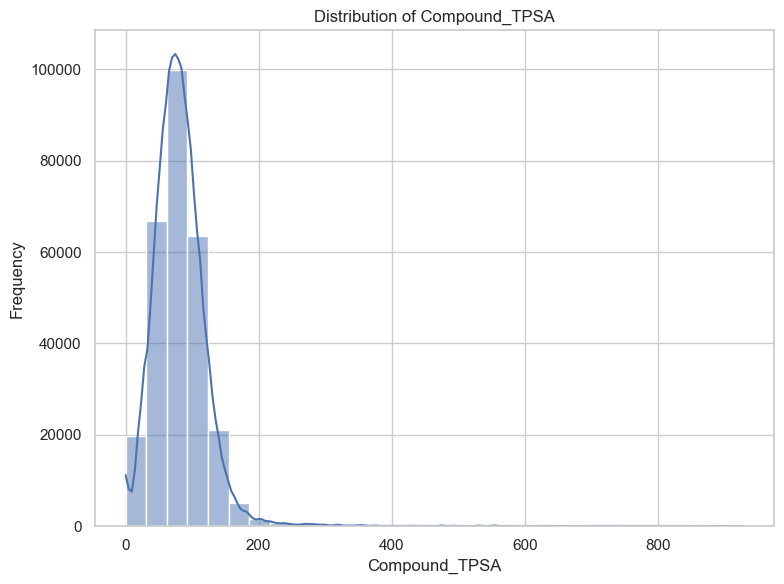

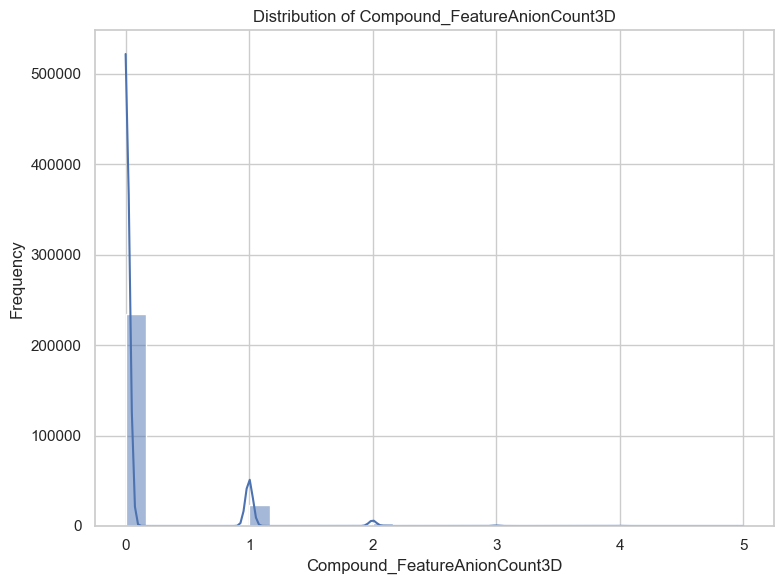

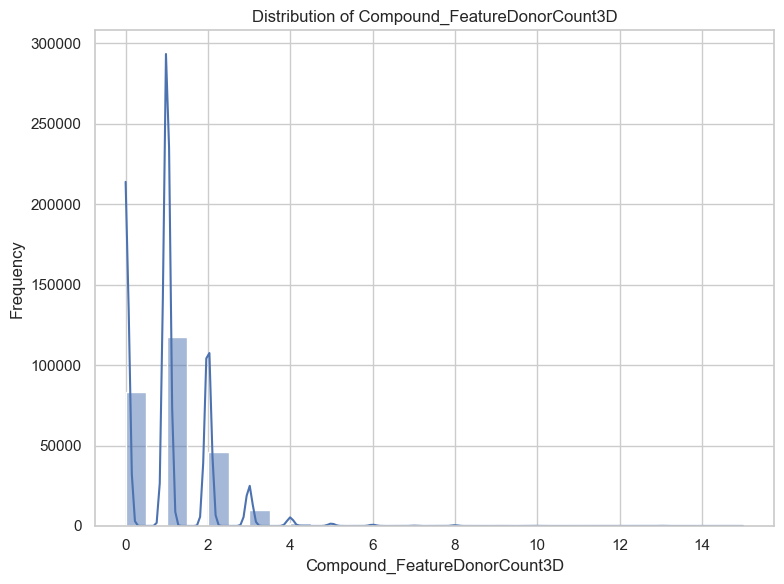

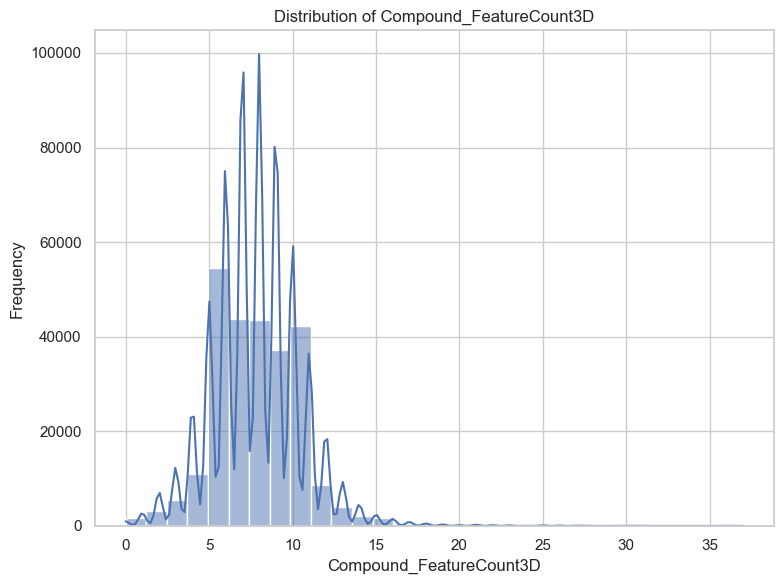

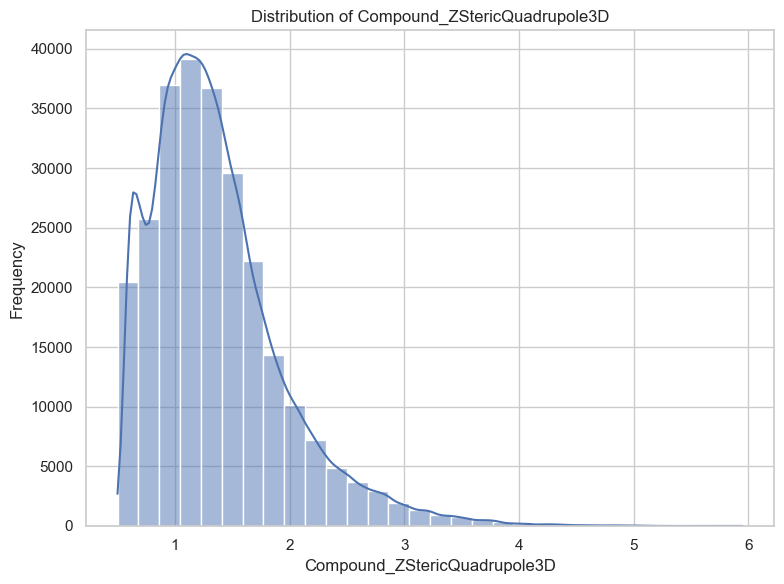

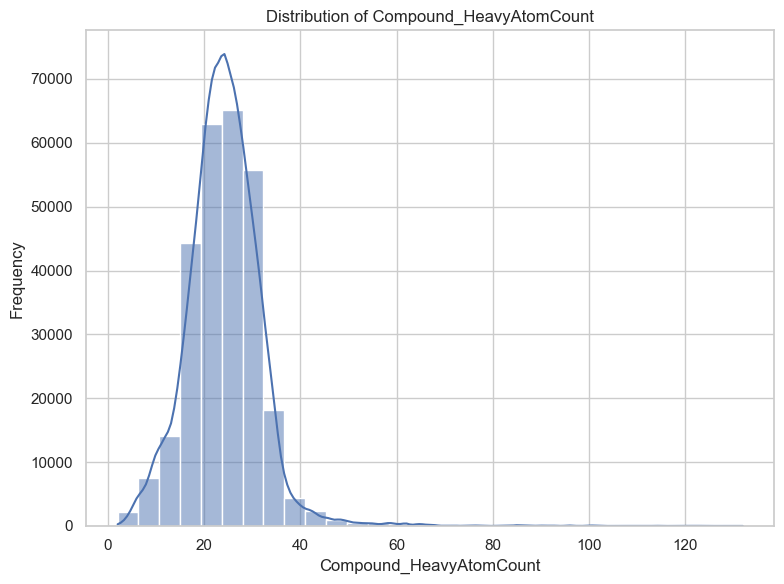

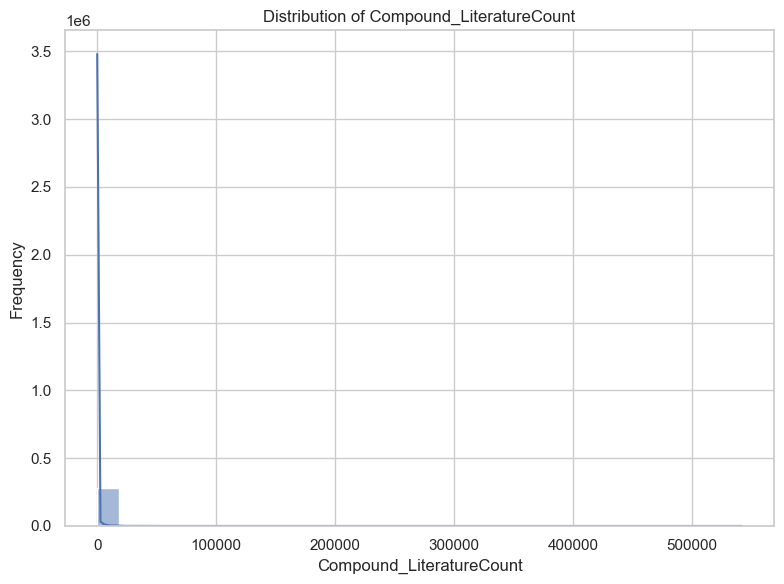

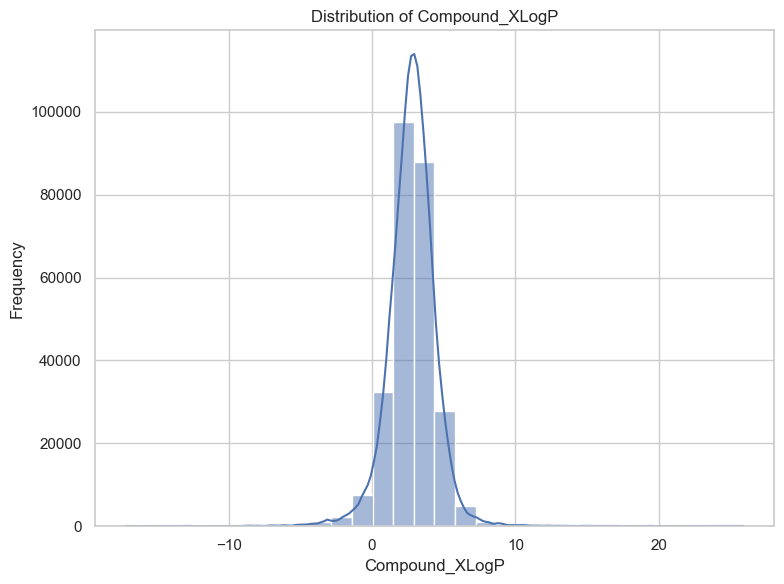

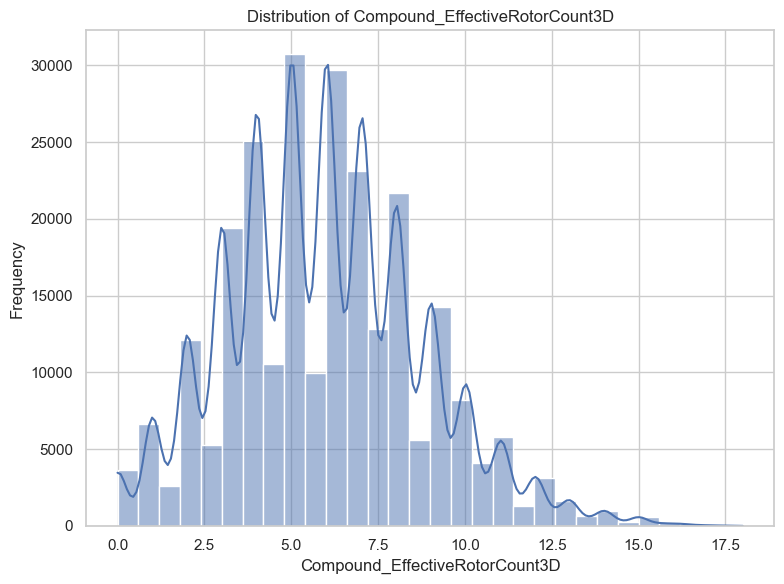

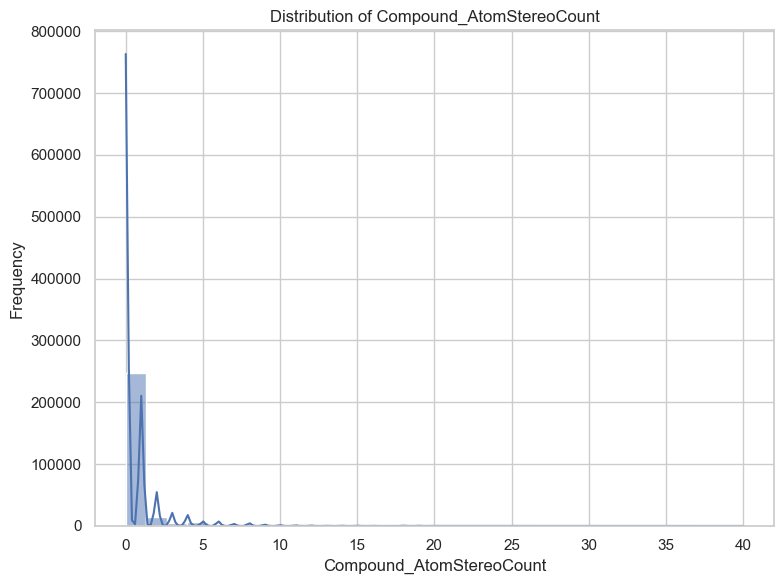

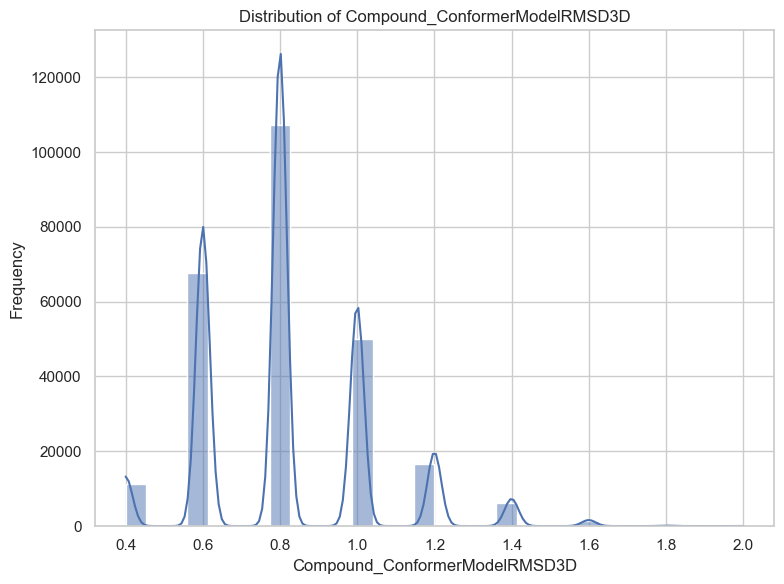

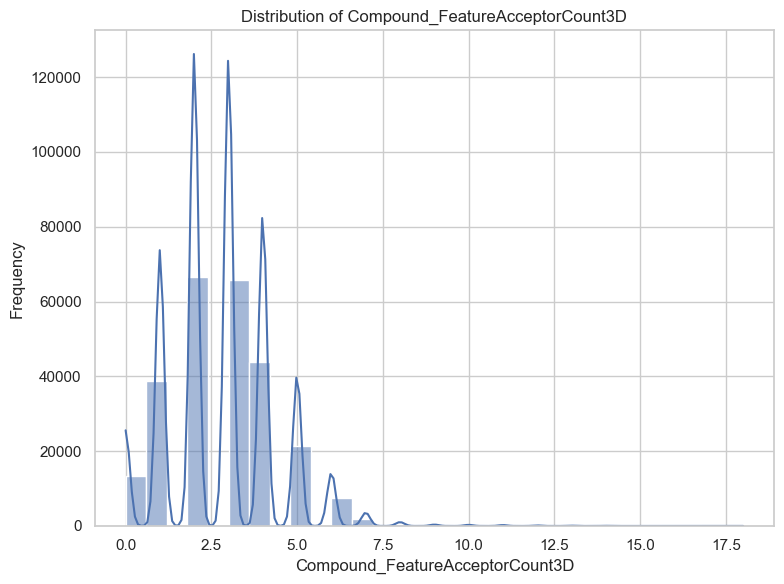

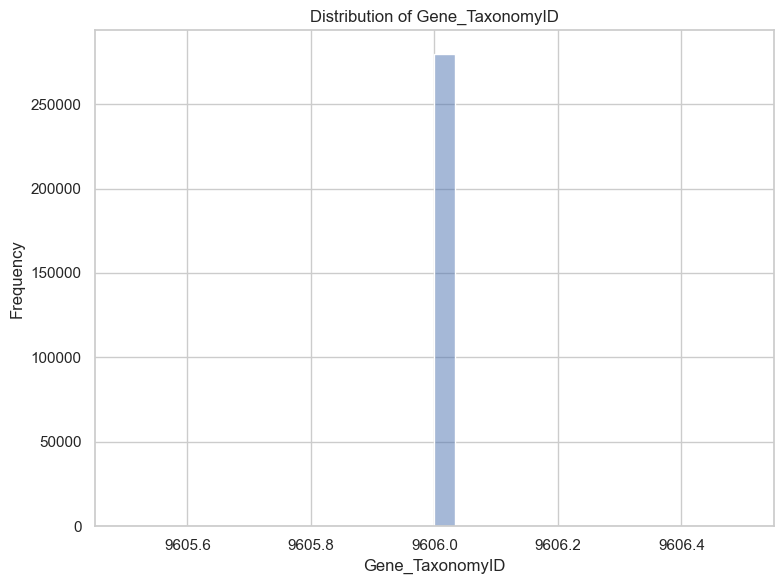

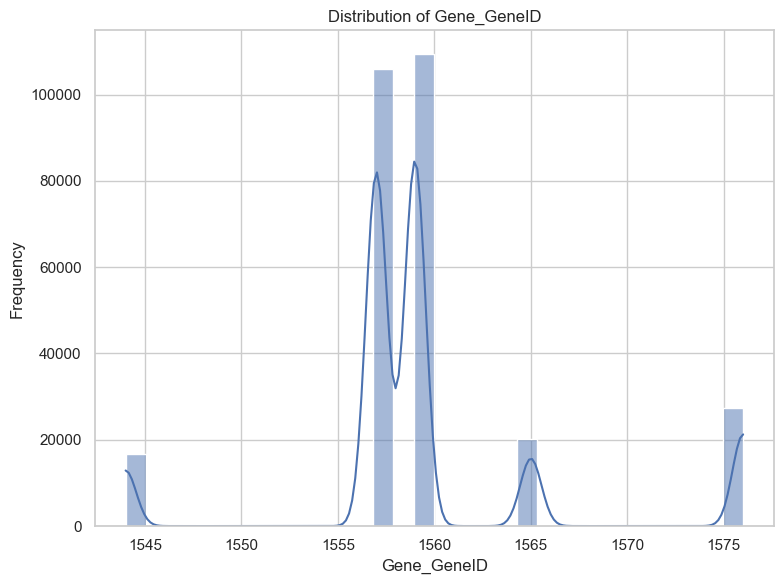

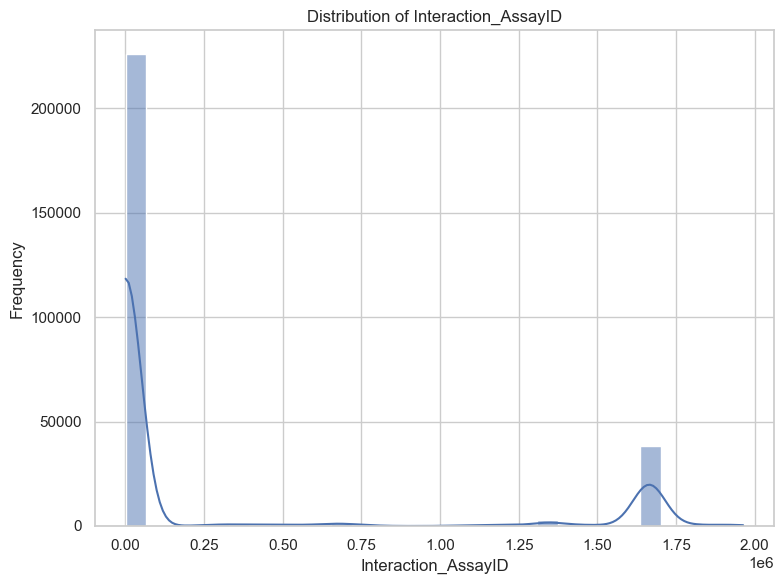

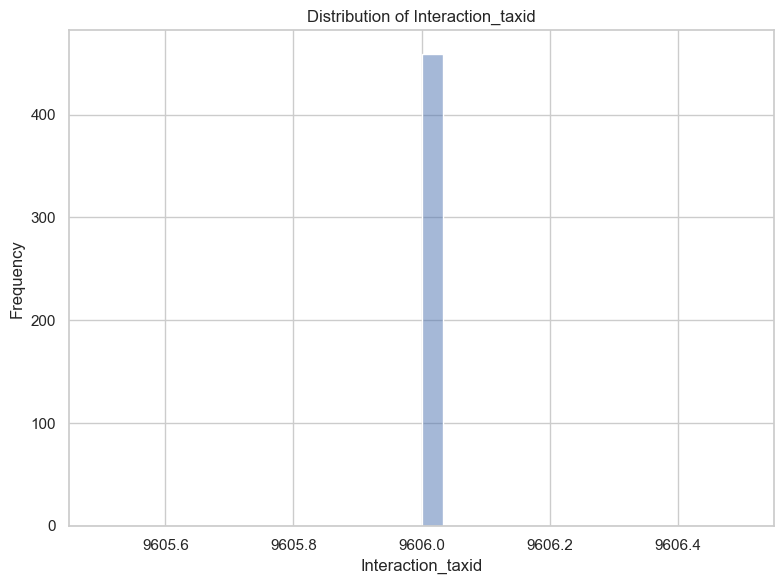

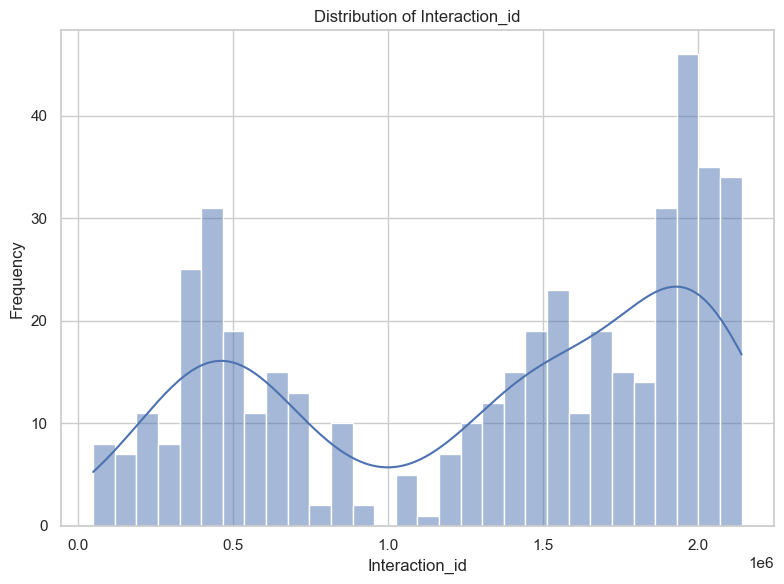

In [16]:
# Histograms: Distribution of numeric features (if any)
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


## Objective

This exploratory data analysis (EDA) investigates interactions between chemical compounds and five major **Cytochrome P450 (CYP450)** enzymes: `CYP1A2`, `CYP2C9`, `CYP2C19`, `CYP2D6`, and `CYP3A4`. These enzymes play a critical role in drug metabolism, influencing bioavailability, efficacy, and potential toxicity. Understanding interaction patterns helps in drug safety profiling and identifying metabolic risks.


In [17]:
data['InteractionType'].nunique()

2

In [22]:
pd.DataFrame(interaction_counts)

,count
InteractionType,
inhibit,29237
inactive,250448


C:\Users\Asmaa_Ali\AppData\Local\Temp\ipykernel_6056\4239071452.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Interaction Type", bbox_to_anchor=(1.05, 1), loc='upper left')


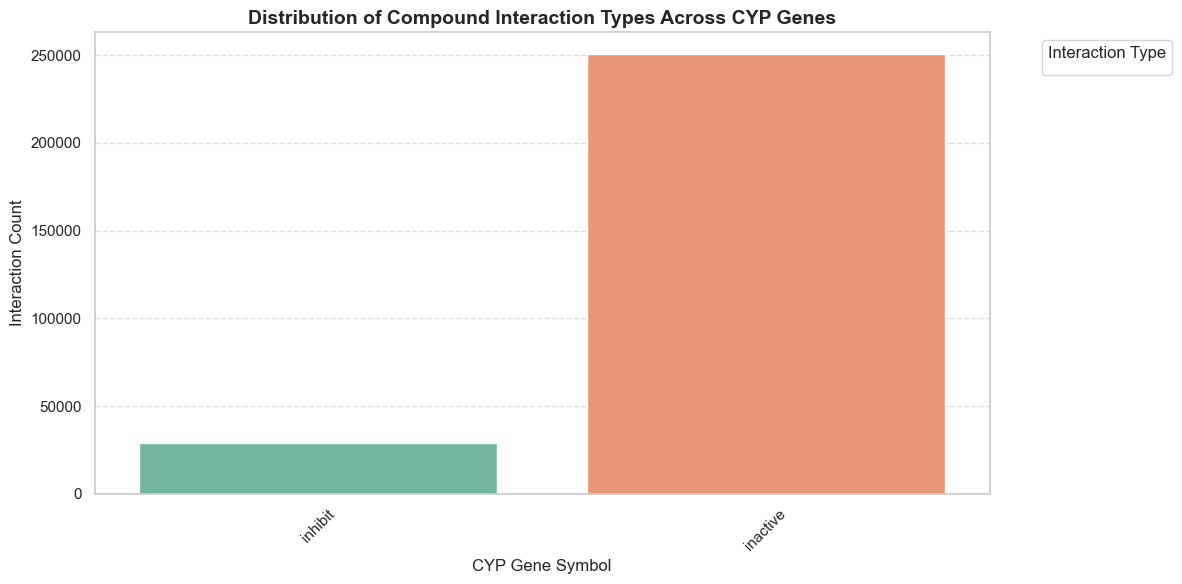

In [24]:

plt.figure(figsize=(12, 6))
palette = sns.color_palette("Set2", n_colors=data['InteractionType'].nunique())
sns.barplot(
    data=pd.DataFrame(interaction_counts),
    x="InteractionType",
    y="count",
    hue="InteractionType",
    palette=palette
)
plt.title("Distribution of Compound Interaction Types Across CYP Genes", fontsize=14, weight='bold')
plt.xlabel("CYP Gene Symbol", fontsize=12)
plt.ylabel("Interaction Count", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Interaction Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


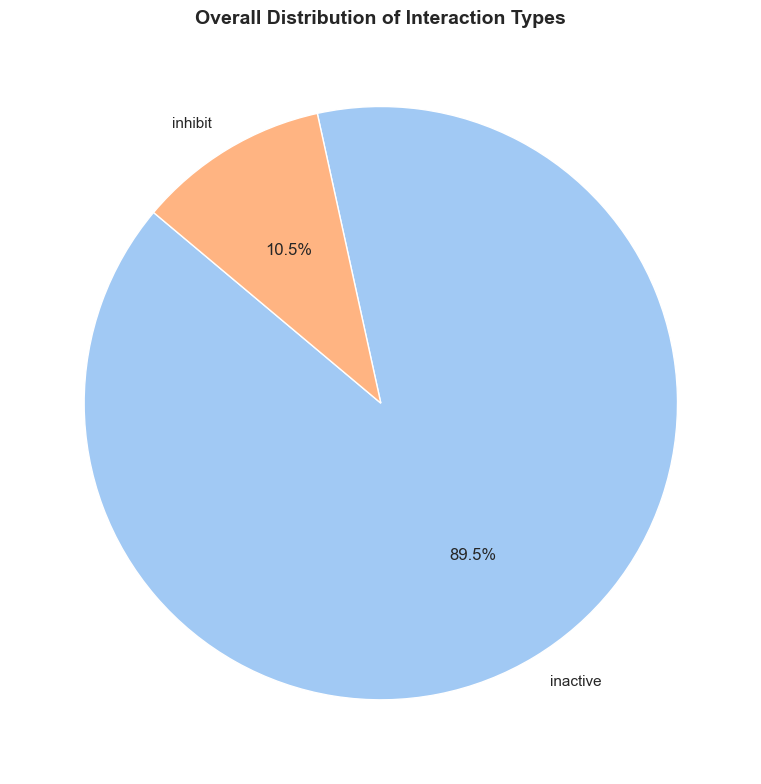

In [25]:

plt.figure(figsize=(8, 8))
colors = sns.color_palette("pastel")[0:len(data['InteractionType'].unique())]
data['InteractionType'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
plt.title("Overall Distribution of Interaction Types", fontsize=14, weight='bold')
plt.ylabel("")
plt.tight_layout()
plt.show()


In [26]:
data

,Compound_IsomericSMILES,Compound_ExactMass,Compound_XStericQuadrupole3D,Compound_InChI,Compound_FeatureCationCount3D,Compound_IsotopeAtomCount,Compound_IUPACName,Compound_Volume3D,Compound_PatentFamilyCount,Compound_StructureImage2DURL,...,Interaction_protname,Interaction_dois,Interaction_evurls,Interaction_protacxn,Interaction_srccmpdname,Interaction_id,Interaction_srctarget,Interaction_dsn,Interaction_actname,Interaction_action
0,COC1=NC=C(C=N1)C2=CC3=C(NC=C3C(=O)C4=C(C=CC(=C...,557.078088,20.53,InChI=1S/C25H15F4N5O4S/c1-38-25-32-9-13(10-33-...,2.0,0,"N-[2,4-difluoro-3-[5-(2-methoxypyrimidin-5-yl)...",391.1,1.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CN1CCN(CC1)CC2=C(C=CC(=C2)NC3=C4C=C(C=CC4=NC5=...,462.182254,9.35,InChI=1S/C26H27ClN4O2/c1-30-9-11-31(12-10-30)1...,3.0,0,4-[(6-chloro-2-methoxyacridin-9-yl)amino]-2-[(...,354.3,6.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,COC(=O)N[C@H](C1=CC=CC=C1)C(=O)N2CCC[C@H]2C(=O...,796.303219,NaN,InChI=1S/C42H42F2N6O8/c1-57-41(55)47-35(25-11-...,NaN,0,methyl N-[(1R)-2-[(2S)-2-[[3-fluoro-4-[2-fluor...,NaN,1.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CC(C)C[C@@H](C(=O)N[C@@H](C[C@@H]1CCNC1=O)C(=O...,575.220240,22.32,InChI=1S/C30H33N5O5S/c1-16(2)13-22(34-29(39)23...,1.0,0,"N-[(2S)-1-[[(2S)-1-(1,3-benzothiazol-2-yl)-1-o...",441.9,3.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CN1C[C@H]2CCCC[C@]2(C1)C3=CC(=C(C=C3)Cl)Cl,283.089455,7.34,"InChI=1S/C15H19Cl2N/c1-18-9-12-4-2-3-7-15(12,1...",1.0,0,"(3aS,7aR)-7a-(3,4-dichlorophenyl)-2-methyl-3,3...",211.6,1.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340059,CCN1CCC[C@H]1CNC(=O)C2=C(C=CC(=C2OC)Br)OC,370.089210,11.37,InChI=1S/C16H23BrN2O3/c1-4-19-9-5-6-11(19)10-1...,1.0,0,3-bromo-N-[[(2S)-1-ethylpyrrolidin-2-yl]methyl...,256.5,723.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,Cytochrome P450 1A2,NaN,https://www.ncbi.nlm.nih.gov/pubmed/8781526,P05177,Remoxipride,1512055.0,BE0002433,DrugBank,NaN,inhibitor
340064,CCN1C=C(C(=O)C2=CC(=C(C=C21)N3CCN(CC3)C)F)C(=O)O,333.148870,13.12,InChI=1S/C17H20FN3O3/c1-3-20-10-12(17(23)24)16...,3.0,0,1-ethyl-6-fluoro-7-(4-methylpiperazin-1-yl)-4-...,251.9,3306.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,Cytochrome P450 1A2,NaN,['https://www.ncbi.nlm.nih.gov/pubmed/19590965...,P05177,Pefloxacin,1510809.0,BE0002433,DrugBank,NaN,inhibitor
340142,CC(=O)OC1=CC=CC2=C1C(=O)C3=C(C2=O)C=C(C=C3OC(=...,368.053217,8.85,InChI=1S/C19H12O8/c1-8(20)26-13-5-3-4-11-15(13...,0.0,0,"4,5-diacetyloxy-9,10-dioxoanthracene-2-carboxy...",265.2,1265.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,Cytochrome P450 1A2,NaN,https://www.ncbi.nlm.nih.gov/pubmed/18814214,P05177,Diacerein,1085892.0,BE0002433,DrugBank,NaN,inhibitor
340168,CCCCCC1=CC(=C2[C@@H]3C=C(CC[C@H]3C(OC2=C1)(C)C...,314.224580,14.60,InChI=1S/C21H30O2/c1-5-6-7-8-15-12-18(22)20-16...,0.0,0,"(6aR,10aR)-6,6,9-trimethyl-3-pentyl-6a,7,8,10a...",260.6,14313.0,https://pubchem.ncbi.nlm.nih.gov/rest/pug/comp...,...,Cytochrome P450 1A2,NaN,['https://www.ncbi.nlm.nih.gov/pubmed/34493602...,P05177,Dronabinol,1222384.0,BE0002433,DrugBank,NaN,inhibitor



## Suggested Thesis Paragraph

In order to explore the diversity and specificity of compound–CYP450 interactions, an extensive exploratory data analysis was conducted on a curated dataset comprising chemical interactions with five key cytochrome P450 enzymes. The analysis revealed diverse interaction types with varying frequencies across genes. A significant subset of compounds showed multi-target activity, indicating potential promiscuity or polypharmacology. Visual analytics, including bar plots, pie charts, and heatmaps, facilitated the identification of dominant interaction patterns per gene and relationships between numerical attributes. These insights support downstream modeling and contribute to mechanistic understanding relevant to drug metabolism and safety profiling.


In [33]:
numeric_cols = [col for col in numeric_cols if "id" not in col.lower()]
numeric_stats = data[numeric_cols].describe()
numeric_stats

,Compound_ExactMass,Compound_XStericQuadrupole3D,Compound_FeatureCationCount3D,Compound_IsotopeAtomCount,Compound_Volume3D,Compound_PatentFamilyCount,Compound_Complexity,Compound_PatentCount,Compound_FeatureHydrophobeCount3D,Compound_MonoisotopicMass,...,Compound_FeatureDonorCount3D,Compound_FeatureCount3D,Compound_ZStericQuadrupole3D,Compound_HeavyAtomCount,Compound_LiteratureCount,Compound_XLogP,Compound_EffectiveRotorCount3D,Compound_AtomStereoCount,Compound_ConformerModelRMSD3D,Compound_FeatureAcceptorCount3D
count,279685.000000,260190.000000,260190.000000,279685.000000,260190.000000,77461.000000,279685.000000,7.746100e+04,260190.000000,279685.000000,...,260190.000000,260190.000000,260190.000000,279685.000000,279685.000000,263392.000000,260190.000000,279685.000000,260190.000000,260190.000000
mean,346.167155,13.175079,0.727326,0.000186,258.474773,4263.206026,482.837785,1.212057e+04,0.316369,346.153599,...,0.984550,7.835178,1.366308,24.132746,598.444268,2.783042,5.961603,0.638901,0.813644,2.766117
std,108.213796,6.660344,0.884303,0.026741,69.355820,15689.750524,218.806117,3.589287e+04,0.639527,108.202141,...,0.937263,2.599859,0.577799,7.666228,6679.987077,1.627703,2.793837,1.663986,0.217443,1.523204
min,30.010565,0.930000,0.000000,0.000000,25.200000,1.000000,0.000000,1.000000e+00,0.000000,30.010565,...,0.000000,0.000000,0.500000,2.000000,0.000000,-17.200000,0.000000,0.000000,0.400000,0.000000
25%,282.109231,8.420000,0.000000,0.000000,215.200000,2.000000,346.000000,7.000000e+00,0.000000,282.107653,...,0.000000,6.000000,0.960000,20.000000,0.000000,1.900000,4.000000,0.000000,0.600000,2.000000
50%,343.135448,11.820000,0.000000,0.000000,259.200000,75.000000,469.000000,2.260000e+02,0.000000,343.135448,...,1.000000,8.000000,1.260000,24.000000,0.000000,2.800000,6.000000,0.000000,0.800000,3.000000
75%,406.179361,16.590000,1.000000,0.000000,304.600000,2505.000000,603.000000,7.828000e+03,0.000000,406.175339,...,1.000000,9.000000,1.630000,28.000000,0.000000,3.700000,8.000000,1.000000,1.000000,4.000000
max,1875.540932,99.010000,6.000000,6.000000,585.700000,963835.000000,3980.000000,1.476513e+06,11.000000,1875.540932,...,15.000000,37.000000,5.950000,132.000000,541692.000000,25.900000,18.000000,40.000000,2.000000,18.000000


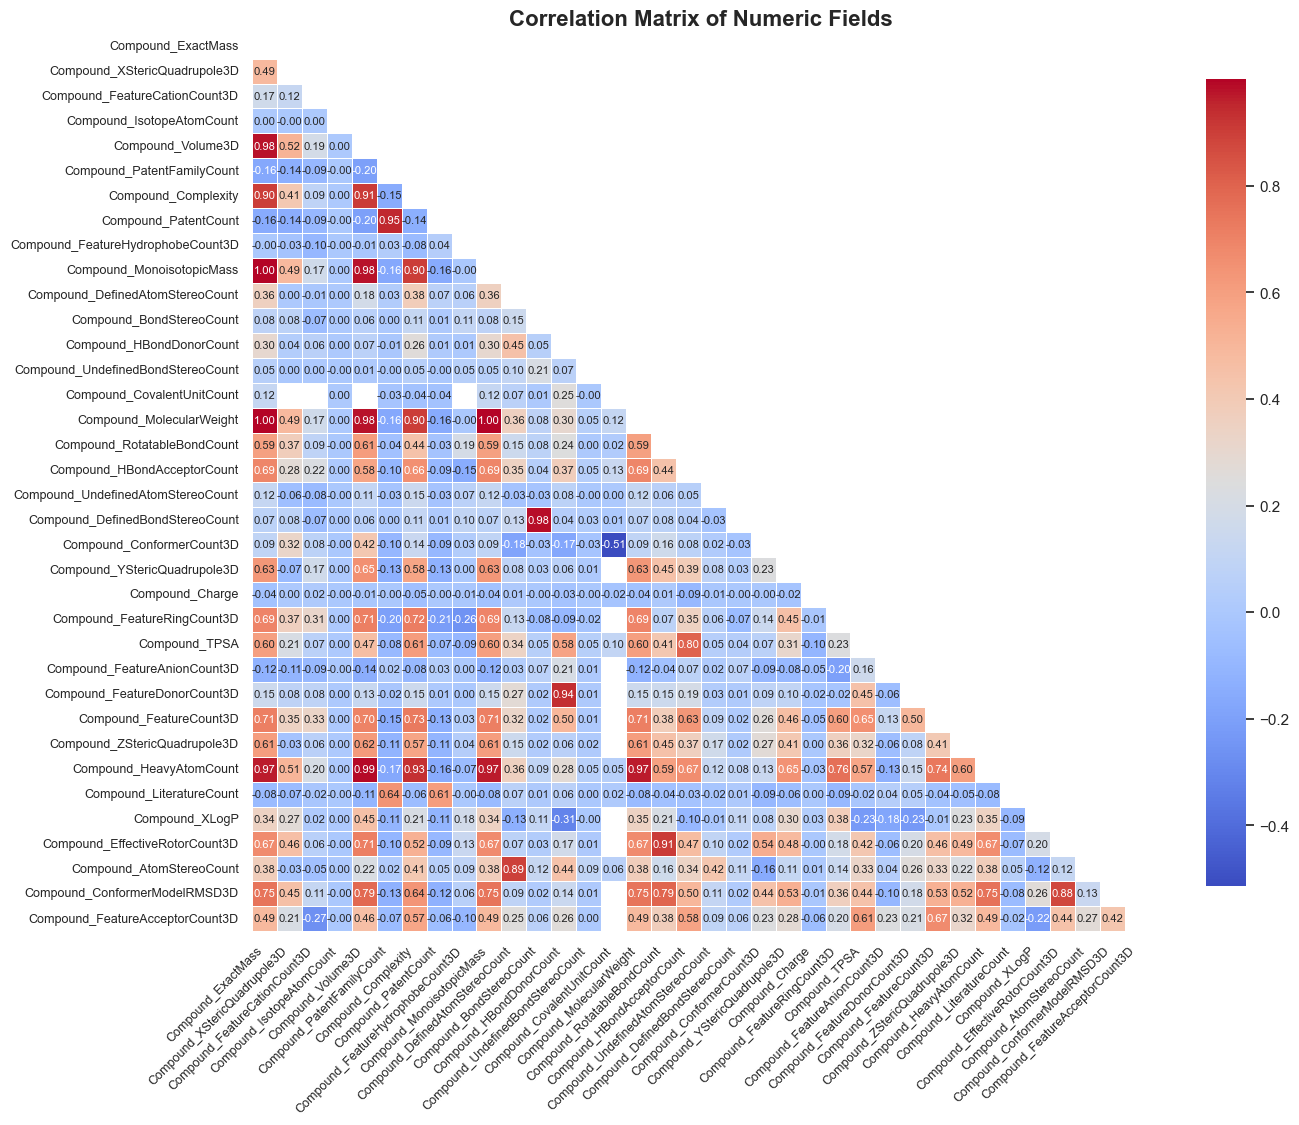

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

if len(numeric_cols) > 1:
    corr = data[numeric_cols].corr()

    plt.figure(figsize=(14, 12))  # Larger size
    sns.set(style="white")  # Clean background

    # Create mask to hide the upper triangle (optional for less clutter)
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Plot heatmap
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": 0.8},
        annot_kws={"fontsize": 8}
    )

    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.title("Correlation Matrix of Numeric Fields", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [30]:
# Dominant interaction type per gene
# Interaction counts by type and gene
interaction_counts = (
    data.groupby(["Gene_GeneSymbol", "InteractionType"])
    .size()
    .reset_index(name="Count")
)

dominant_interactions = interaction_counts.loc[
    interaction_counts.groupby('Gene_GeneSymbol')['Count'].idxmax()
]
dominant_interactions

,Gene_GeneSymbol,InteractionType,Count
0,CYP1A2,inactive,9015
2,CYP2C19,inactive,102028
4,CYP2C9,inactive,103670
6,CYP2D6,inactive,15161
8,CYP3A4,inactive,20574
